# 🚀 Mini Portfolio Assignment — E-Commerce Sales Analysis
## Data Analytics Bootcamp

---
**Nama    :** _(Perdana Semeru Ashaalatur Rayi)_  
**Tanggal :** _(16 Mei 2026)_  
**Dataset :** [Online Retail Dataset](https://archive.ics.uci.edu/dataset/352/online+retail)

### Tujuan Analisis
Sebagai Junior Data Analyst, kita diminta menganalisis data penjualan e-commerce untuk:
1. Memahami performa penjualan per kategori & region
2. Mengidentifikasi dampak diskon terhadap profitabilitas
3. Menemukan pola musiman (seasonal trend)
4. Memberikan rekomendasi bisnis yang actionable

---


## Cell 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
})
sns.set_palette("husl")

print("✅ Libraries berhasil di-import!")
print(f"   Pandas v{pd.__version__} | NumPy v{np.__version__}")


✅ Libraries berhasil di-import!
   Pandas v2.2.2 | NumPy v2.0.2


## Cell 2 — Load Data


In [2]:
try:
    # Loading the Excel file
    df_raw = pd.read_excel('/content/online_retail.xlsx')
    print("✅ File online_retail.xlsx berhasil dimuat!")

    # Display basic info
    print(f"\n📐 Shape: {df_raw.shape[0]:,} baris × {df_raw.shape[1]} kolom")
    display(df_raw.head())
except Exception as e:
    print(f"❌ Gagal memuat file: {e}")

✅ File online_retail.xlsx berhasil dimuat!

📐 Shape: 541,909 baris × 8 kolom


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
# Rename kolom biar nanti ga perlu replace manual kode lama
df_raw = df_raw.rename(columns={'InvoiceDate': 'Order Date', 'InvoiceNo': 'Order ID'})


## Cell 3 — Step 1: Data Exploration

In [4]:
print("=== INFO DATASET ===")
df_raw.info()


=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Order ID     541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   Order Date   541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [5]:
print("=== STATISTIK DESKRIPTIF ===")
df_raw.describe().round(2)


=== STATISTIK DESKRIPTIF ===


,Quantity,Order Date,UnitPrice,CustomerID
count,541909.00,541909,541909.00,406829.00
mean,9.55,2011-07-04 13:34:57.156386048,4.61,15287.69
min,-80995.00,2010-12-01 08:26:00,-11062.06,12346.00
25%,1.00,2011-03-28 11:34:00,1.25,13953.00
50%,3.00,2011-07-19 17:17:00,2.08,15152.00
75%,10.00,2011-10-19 11:27:00,4.13,16791.00
max,80995.00,2011-12-09 12:50:00,38970.00,18287.00
std,218.08,NaN,96.76,1713.60


In [6]:
print("=== MISSING VALUES ===")
missing = df_raw.isnull().sum()
pct     = (missing / len(df_raw) * 100).round(2)
pd.DataFrame({"Count": missing, "Pct %": pct})[missing > 0]


=== MISSING VALUES ===


,Count,Pct %
Description,1454,0.27
CustomerID,135080,24.93


Lihat data dengan missing value.


In [7]:
# 1. Inspect rows with missing Description
print("--- SAMPLE: MISSING DESCRIPTION ---")
missing_desc = df_raw[df_raw['Description'].isnull()]
display(missing_desc.head(10))

# 2. Inspect rows with missing CustomerID
print("\n--- SAMPLE: MISSING CUSTOMERID ---")
missing_cust = df_raw[df_raw['CustomerID'].isnull()]
display(missing_cust.head(10))

# 3. Check if any rows are missing BOTH
both_missing = df_raw[df_raw['Description'].isnull() & df_raw['CustomerID'].isnull()]
print(f"\nRows missing both Description & CustomerID: {len(both_missing):,}")

--- SAMPLE: MISSING DESCRIPTION ---


,Order ID,StockCode,Description,Quantity,Order Date,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom



--- SAMPLE: MISSING CUSTOMERID ---


,Order ID,StockCode,Description,Quantity,Order Date,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom
1447,536544,21790,VINTAGE SNAP CARDS,9,2010-12-01 14:32:00,1.66,NaN,United Kingdom
1448,536544,21791,VINTAGE HEADS AND TAILS CARD GAME,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1449,536544,21801,CHRISTMAS TREE DECORATION WITH BELL,10,2010-12-01 14:32:00,0.43,NaN,United Kingdom
1450,536544,21802,CHRISTMAS TREE HEART DECORATION,9,2010-12-01 14:32:00,0.43,NaN,United Kingdom
1451,536544,21803,CHRISTMAS TREE STAR DECORATION,11,2010-12-01 14:32:00,0.43,NaN,United Kingdom



Rows missing both Description & CustomerID: 1,454


In [8]:
print("COUNTRIES BY TRANSACTION COUNT:")
display(df_raw['Country'].value_counts())

print("\nTOP 30 PRODUCTS (by Description):")
display(df_raw['Description'].value_counts().head(30))

print("\nTOP 10 CUSTOMERS (by transaction frequency):")
display(df_raw['CustomerID'].value_counts().head(10))

COUNTRIES BY TRANSACTION COUNT:


,count
Country,
United Kingdom,495478
Germany,9495
France,8557
EIRE,8196
Spain,2533
Netherlands,2371
Belgium,2069
Switzerland,2002
Portugal,1519



TOP 30 PRODUCTS (by Description):


,count
Description,
WHITE HANGING HEART T-LIGHT HOLDER,2369
REGENCY CAKESTAND 3 TIER,2200
JUMBO BAG RED RETROSPOT,2159
PARTY BUNTING,1727
LUNCH BAG RED RETROSPOT,1638
ASSORTED COLOUR BIRD ORNAMENT,1501
SET OF 3 CAKE TINS PANTRY DESIGN,1473
PACK OF 72 RETROSPOT CAKE CASES,1385
LUNCH BAG BLACK SKULL.,1350



TOP 10 CUSTOMERS (by transaction frequency):


,count
CustomerID,
17841.0,7983
14911.0,5903
14096.0,5128
12748.0,4642
14606.0,2782
15311.0,2491
14646.0,2085
13089.0,1857
13263.0,1677


## Cell 4 — Step 2: Data Cleaning

In [26]:
# 1. Create a working copy
df = df_raw.copy()

# 2. Handle missing CustomerID
df['CustomerID'] = df['CustomerID'].fillna('Guest Checkout')

# 3. Drop rows with missing Description
df.dropna(subset=['Description'], inplace=True)

# 4. Create 'Net_Sales' column for the full dataset (including negatives)
df['Net_Sales'] = df['Quantity'] * df['UnitPrice']

# 5. Create df_sales for positive sales analysis
df_sales = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()

# 6. Define service-only codes
service_codes = ['DOTCOM POSTAGE', 'POSTAGE', 'MANUAL', 'AMAZON FEE', 'BANK CHARGES', 'CRUK COMMISSION', 'SAMPLES', 'DISCOUNT']

# 7. Categorize and Feature Engineering (on df_sales)
df_sales['Item_Type'] = df_sales['Description'].apply(lambda x: 'Service Fee' if str(x).upper().strip() in service_codes else 'Physical Product')
df_sales['Sales'] = df_sales['Quantity'] * df_sales['UnitPrice']
df_sales['Year'] = df_sales['Order Date'].dt.year
df_sales['Month'] = df_sales['Order Date'].dt.month
df_sales['Month_Name'] = df_sales['Order Date'].dt.strftime('%b')
df_sales['Hour'] = df_sales['Order Date'].dt.hour

print(f"✅ Simplified cleaning complete. `df` (all transactions) and `df_sales` (positive only) are ready.")
display(df_sales['Item_Type'].value_counts())

✅ Simplified cleaning complete. `df` (all transactions) and `df_sales` (positive only) are ready.


,count
Item_Type,
Physical Product,527934
Service Fee,2170


### Segregating Fees & Services
To keep our product analysis accurate, we separate non-product entries (Postage, Fees, etc.) into a dedicated DataFrame.

In [27]:
# 1. Create a separate DataFrame for Service Fees
df_fees = df[df['Description'].str.upper().str.strip().isin(service_codes)].copy()
df_fees['Sales'] = df_fees['Quantity'] * df_fees['UnitPrice']

# 2. Update df_sales to EXCLUDE fees entirely
# This ensures our sales analysis only looks at physical product inventory
df_sales = df_sales[df_sales['Item_Type'] == 'Physical Product'].copy()

print(f"📦 Physical Products remaining in df_sales: {len(df_sales):,}")
print(f"🏷️  Service Fees moved to df_fees: {len(df_fees):,}")

# Display summary of fees
display(df_fees.groupby('Description')['Sales'].sum().sort_values(ascending=False))

📦 Physical Products remaining in df_sales: 527,934
🏷️  Service Fees moved to df_fees: 2,761


,Sales
Description,
DOTCOM POSTAGE,206245.480
POSTAGE,66230.640
samples,0.000
SAMPLES,-3049.390
Discount,-5696.220
Bank Charges,-7175.639
CRUK Commission,-7933.430
Manual,-68671.640
AMAZON FEE,-221520.500


## Cell 5 — Step 3: Sales Analysis
### KPI Summary

In [28]:
# Calculate KPIs for Online Retail dataset (UK-based retailer -> £)
total_revenue = df_sales["Sales"].sum()
total_orders  = df_sales["Order ID"].nunique()
total_items   = df_sales["Quantity"].sum()
avg_order_val = total_revenue / total_orders
unique_cust   = df_sales["CustomerID"].nunique()

kpi = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Total Transactions",
        "Total Items Sold",
        "Average Order Value",
        "Unique Customers"
    ],
    "Value": [
        f"£{total_revenue:,.2f}",
        f"{total_orders:,}",
        f"{total_items:,}",
        f"£{avg_order_val:,.2f}",
        f"{unique_cust:,}"
    ]
})
display(kpi)

,KPI,Value
0,Total Revenue,"£10,290,231.93"
1,Total Transactions,"19,777"
2,Total Items Sold,"5,577,279"
3,Average Order Value,£520.31
4,Unique Customers,"4,335"


### Top 10 Demands
Produk-produk yang paling banyak dibeli (belum termasuk barang return, dan sudah termasuk pembelian dari guest account atau CustomerID kosong)

In [29]:
# Grouping ONLY physical products to find actual top inventory items (positive sales)
top_products = df_sales[df_sales['Item_Type'] == 'Physical Product'].groupby("Description").agg(
    Total_Sales=("Sales", "sum"),
    Quantity_Sold=("Quantity", "sum")
).sort_values("Total_Sales", ascending=False).head(10)

print("🏆 TOP 10 PHYSICAL PRODUCTS BY REVENUE (Excluding Service Fees, only positive sales)")
display(top_products.style.format({
    "Total_Sales": "£{:,.2f}",
    "Quantity_Sold": "{:,}"
}))

🏆 TOP 10 PHYSICAL PRODUCTS BY REVENUE (Excluding Service Fees, only positive sales)


,Total_Sales,Quantity_Sold
Description,,
REGENCY CAKESTAND 3 TIER,"£174,484.74","13,879"
"PAPER CRAFT , LITTLE BIRDIE","£168,469.60","80,995"
WHITE HANGING HEART T-LIGHT HOLDER,"£106,292.77","37,891"
PARTY BUNTING,"£99,504.33","18,295"
JUMBO BAG RED RETROSPOT,"£94,340.05","48,474"
MEDIUM CERAMIC TOP STORAGE JAR,"£81,700.92","78,033"
RABBIT NIGHT LIGHT,"£66,964.99","30,788"
PAPER CHAIN KIT 50'S CHRISTMAS,"£64,952.29","19,355"
ASSORTED COLOUR BIRD ORNAMENT,"£59,094.93","36,461"


## Cell 6 — Step 4: Visualisasi
### Dashboard (4 Charts)

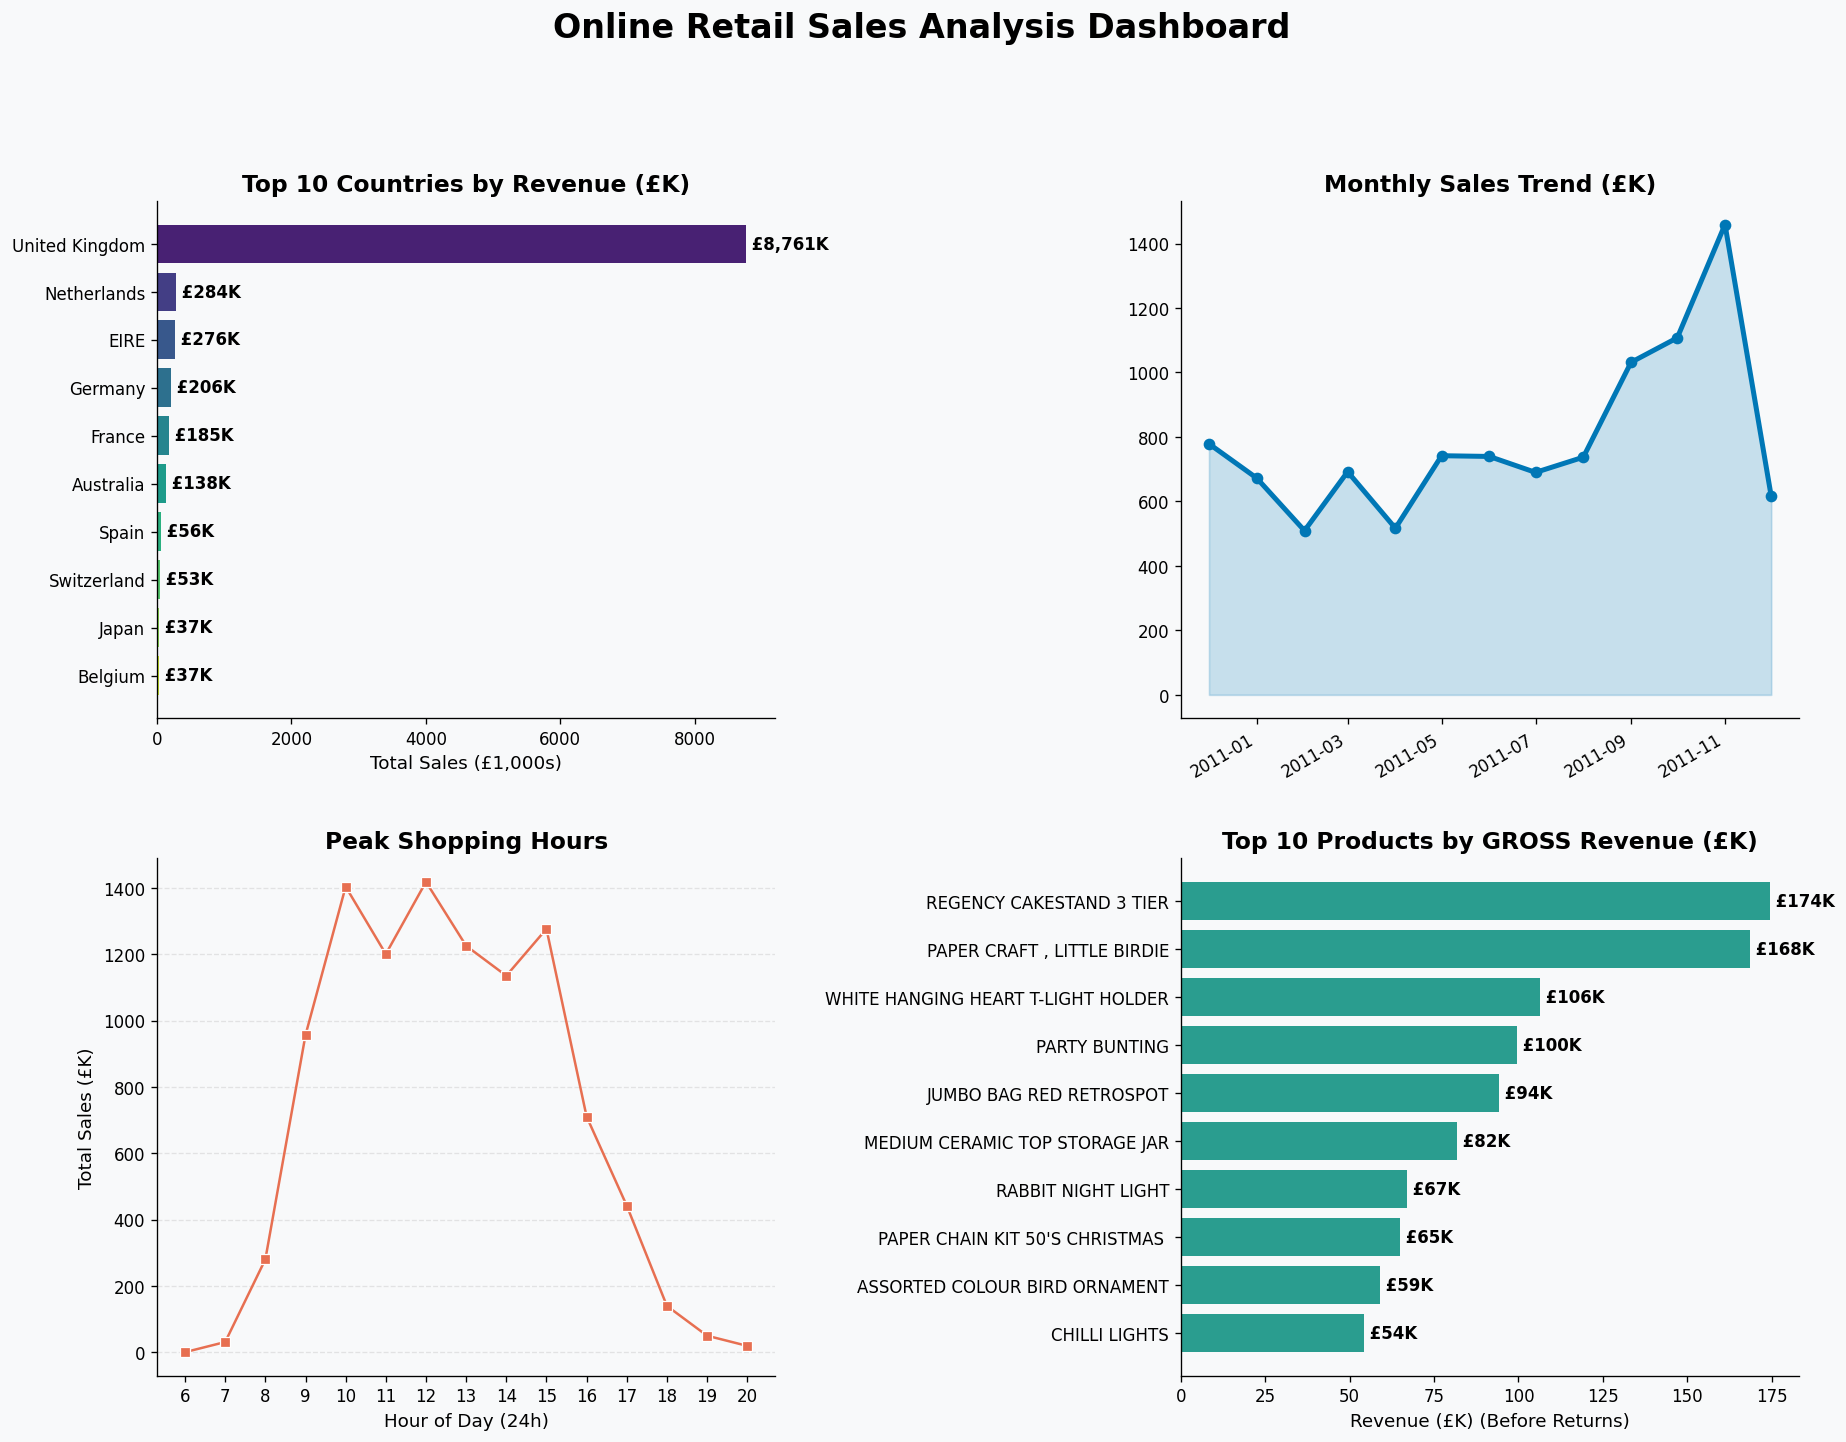

✅ Dashboard disimpan ke online_retail_gross.png


In [31]:
# 1. Prepare Data for Visuals
# Monthly Sales Trend
monthly_sales = df_sales.groupby(['Year', 'Month']).agg(Sales=('Sales', 'sum')).reset_index()
monthly_sales['Date'] = pd.to_datetime(monthly_sales[['Year', 'Month']].assign(Day=1))
monthly_sales = monthly_sales.sort_values('Date')

# Top 10 Countries by Sales
top_countries = df_sales.groupby('Country').agg(Sales=('Sales', 'sum')).sort_values('Sales', ascending=False).head(10)

# Hourly Sales Pattern
hourly_sales = df_sales.groupby('Hour').agg(Sales=('Sales', 'sum'))

# 2. Setup Figure
FIG_COLOR = "#F8F9FA"
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor(FIG_COLOR)
fig.suptitle("Online Retail Sales Analysis Dashboard", fontsize=20, fontweight="bold", y=1.02)

# Chart 1 — Top 10 Countries by Revenue
ax1 = axes[0,0]; ax1.set_facecolor(FIG_COLOR)
val1 = top_countries['Sales']/1000
bars1 = ax1.barh(top_countries.index, val1, color=sns.color_palette("viridis", 10))
ax1.invert_yaxis()  # Put the highest at the top
ax1.set_title("Top 10 Countries by Revenue (£K)")
ax1.set_xlabel("Total Sales (£1,000s)")
# Add annotations
for bar in bars1:
    width = bar.get_width()
    ax1.text(width, bar.get_y() + bar.get_height()/2, f' £{width:,.0f}K', va='center', fontweight='bold')

# Chart 2 — Monthly Revenue Trend
ax2 = axes[0,1]; ax2.set_facecolor(FIG_COLOR)
ax2.plot(monthly_sales['Date'], monthly_sales['Sales']/1000, marker='o', color='#0077B6', lw=3)
ax2.fill_between(monthly_sales['Date'], monthly_sales['Sales']/1000, alpha=0.2, color='#0077B6')
ax2.set_title("Monthly Sales Trend (£K)")
plt.setp(ax2.get_xticklabels(), rotation=30, ha="right")

# Chart 3 — Sales by Hour of Day
ax3 = axes[1,0]; ax3.set_facecolor(FIG_COLOR)
sns.lineplot(x=hourly_sales.index, y=hourly_sales['Sales']/1000, ax=ax3, color='#E76F51', marker='s')
ax3.set_title("Peak Shopping Hours")
ax3.set_xticks(range(6, 21))
ax3.set_xlabel("Hour of Day (24h)")
ax3.set_ylabel("Total Sales (£K)")
ax3.grid(axis='y', ls='--', alpha=0.3)

# Chart 4 — Top 10 Products by GROSS Revenue (not including returns)
ax4 = axes[1,1]; ax4.set_facecolor(FIG_COLOR)
top_prod_plot = top_products.head(10).sort_values('Total_Sales')
val4 = top_prod_plot['Total_Sales']/1000
bars4 = ax4.barh(top_prod_plot.index, val4, color='#2A9D8F')
ax4.set_title("Top 10 Products by GROSS Revenue (£K)") # Updated title
ax4.set_xlabel("Revenue (£K) (Before Returns)")
# Add annotations
for bar in bars4:
    width = bar.get_width()
    ax4.text(width, bar.get_y() + bar.get_height()/2, f' £{width:,.0f}K', va='center', fontweight='bold')

plt.tight_layout(pad=3.0)
plt.savefig("online_retail_gross.png", bbox_inches="tight", dpi=150, facecolor=FIG_COLOR)
plt.show()
print("✅ Dashboard disimpan ke online_retail_gross.png")

### Bonus: Heatmap Sales

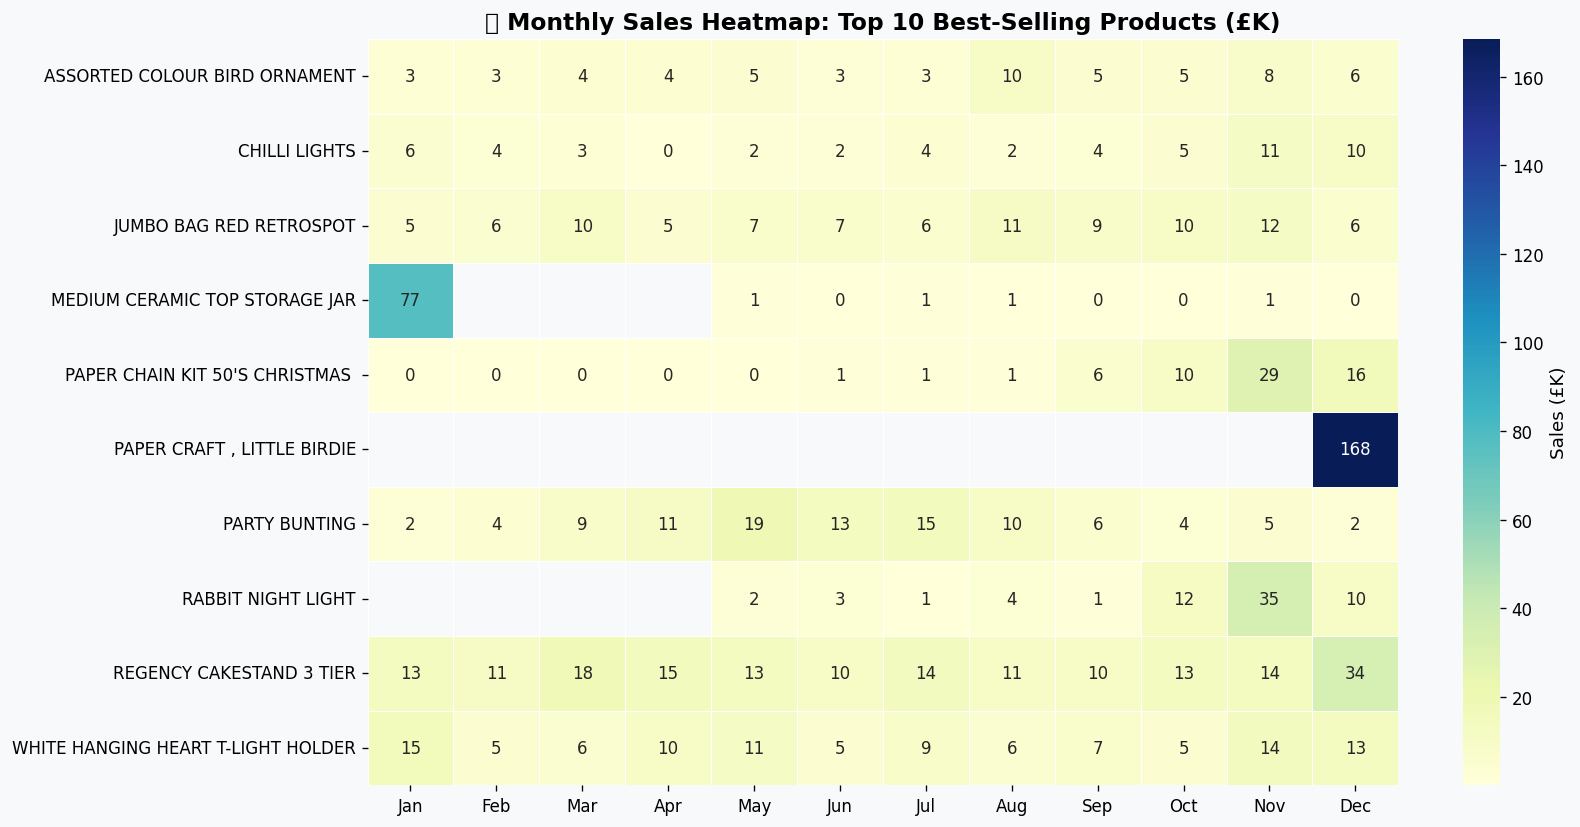

✅ Product heatmap saved as product_heatmap.png


In [32]:
fig_h, ax_h = plt.subplots(figsize=(14, 7))
fig_h.patch.set_facecolor("#F8F9FA"); ax_h.set_facecolor("#F8F9FA")

# 1. Filter for Top 10 Products (already calculated in top_products, which uses df_sales)
top_10_prod_names = top_products.index.tolist()
df_top_prod = df_sales[df_sales['Description'].isin(top_10_prod_names)] # Use df_sales here

# 2. Create Pivot Table: Description vs Month
hm_prod = df_top_prod.pivot_table(values="Sales", index="Description", columns="Month", aggfunc="sum")

# 3. Reorder months and rename
month_map = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun', 7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
hm_prod.columns = [month_map[m] for m in hm_prod.columns]

# 4. Plot Heatmap (Normalized by £K for readability)
sns.heatmap(hm_prod/1000, annot=True, fmt=".0f", cmap="YlGnBu",
            linewidths=0.5, linecolor="white", ax=ax_h,
            cbar_kws={"label": "Sales (£K)"})

ax_h.set_title("🗓️ Monthly Sales Heatmap: Top 10 Best-Selling Products (£K)", fontsize=14, fontweight="bold")
ax_h.set_xlabel(""); ax_h.set_ylabel("")

plt.tight_layout()
plt.savefig("product_heatmap.png", bbox_inches="tight", dpi=150, facecolor=FIG_COLOR)
plt.show()
print("✅ Product heatmap saved as product_heatmap.png")

### International Market Trend Selain di UK
Karena UK mendominasi penjualan, maka disini diperlihatkan market trend di negara top 5 dengan penjualan tertinggi.


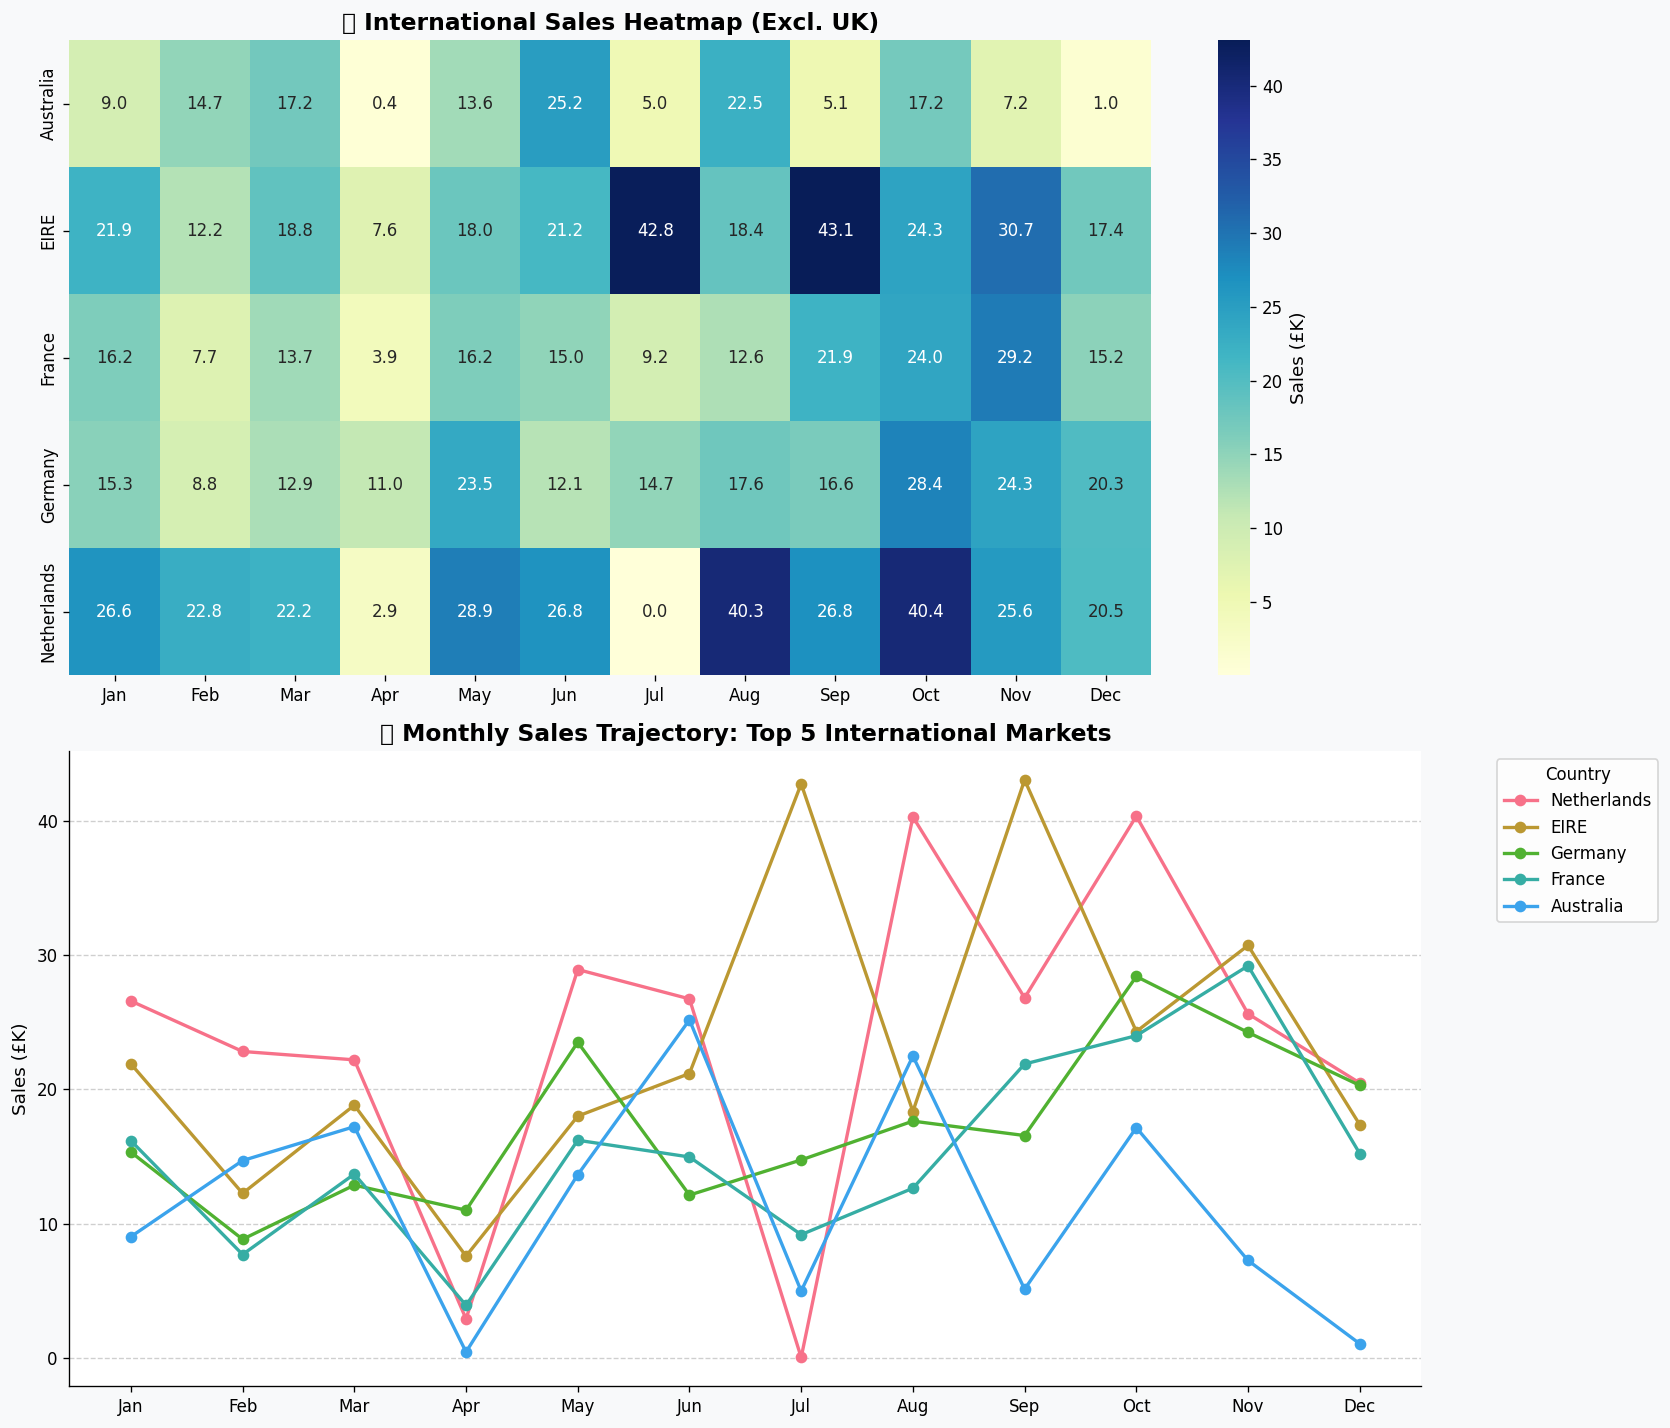

✅ International analysis saved as international_sales_analysis.png


In [33]:
# 1. Get Top 5 Countries excluding UK
# Use df_sales for country sales as it reflects positive transactions
int_countries = df_sales[df_sales['Country'] != 'United Kingdom'].groupby('Country')['Sales'].sum().sort_values(ascending=False).head(5).index.tolist()
df_int = df_sales[df_sales['Country'].isin(int_countries)] # Use df_sales here

# 2. Prepare Monthly Data
# Using Month from df_sales which has already been engineered
hm_int = df_int.pivot_table(values="Sales", index="Country", columns="Month", aggfunc="sum")
month_map = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun', 7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
hm_int.columns = [month_map[m] for m in hm_int.columns]

# 3. Plot
fig, (ax_main, ax_trend) = plt.subplots(2, 1, figsize=(14, 12), gridspec_kw={'height_ratios': [1, 1]})
fig.patch.set_facecolor("#F8F9FA")

# Heatmap for relative performance
sns.heatmap(hm_int/1000, annot=True, fmt=".1f", cmap="YlGnBu", ax=ax_main, cbar_kws={'label': 'Sales (£K)'})
ax_main.set_title("📊 International Sales Heatmap (Excl. UK)", fontsize=14, fontweight='bold')
ax_main.set_ylabel("")

# Line chart for growth trajectory
for country in int_countries:
    data = hm_int.loc[country]
    ax_trend.plot(data.index, data.values/1000, marker='o', label=country, lw=2)

ax_trend.set_title("📈 Monthly Sales Trajectory: Top 5 International Markets", fontsize=14, fontweight='bold')
ax_trend.set_ylabel("Sales (£K)")
ax_trend.legend(title="Country", bbox_to_anchor=(1.05, 1), loc='upper left')
ax_trend.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("international_sales_analysis.png", bbox_inches="tight", dpi=150, facecolor=FIG_COLOR)
plt.show()
print("✅ International analysis saved as international_sales_analysis.png")

### Analisis Pengeluaran
Identifikasi produk apa saja yang menghasilkan pengeluaran (biaya administrasi, item return)

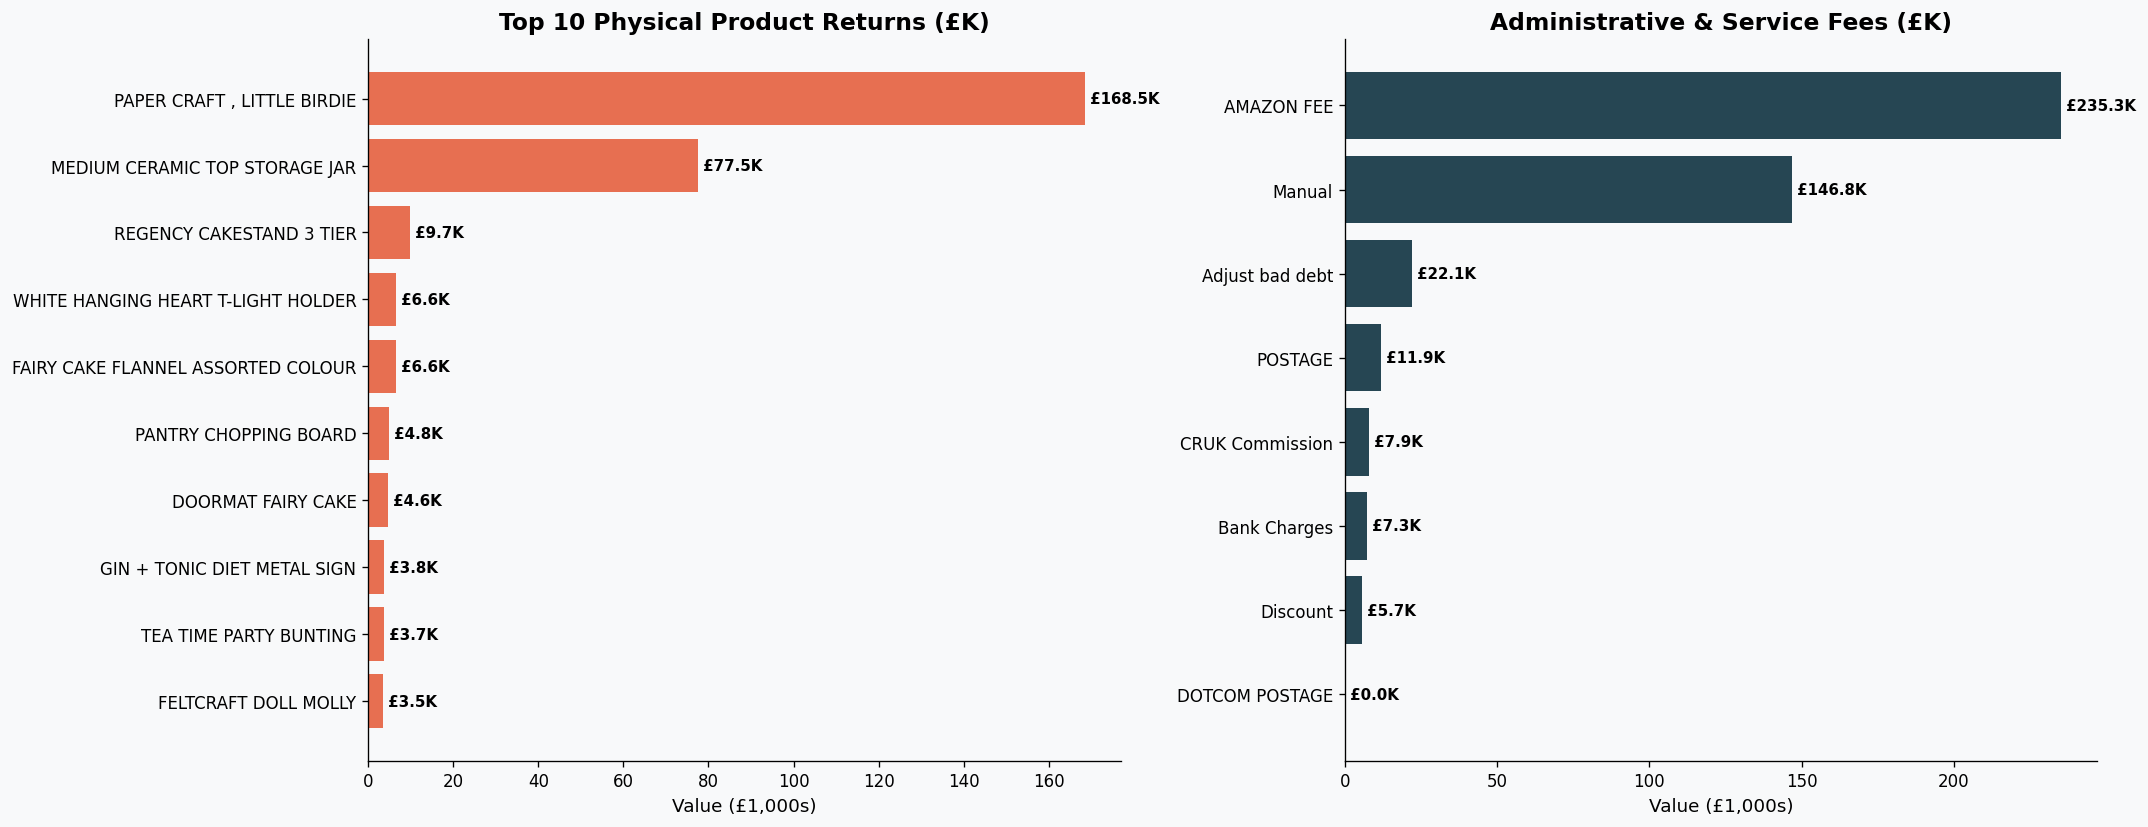

✅ Loss analysis and saved to detailed_loss_analysis_v3.png


In [75]:
# 1. Refined Identification of Expenses vs. Products
# Removed 'SAMPLES' to clean up the chart per user request
admin_markers = ['AMAZON FEE', 'MANUAL', 'POSTAGE', 'DOTCOM POSTAGE', 'CRUK COMMISSION', 'ADJUST', 'DISCOUNT', 'BANK CHARGES']

# Use 'df' here, which contains Net_Sales and cleaned CustomerID/Description
all_losses = df[(df['Quantity'] < 0) | (df['UnitPrice'] < 0)].copy()
all_losses['Loss_Value'] = all_losses['Quantity'].abs() * all_losses['UnitPrice'].abs()

# 2. Precision Categorization
def categorize_loss_refined(desc):
    desc_str = str(desc).upper().strip()
    if any(desc_str.startswith(marker) for marker in admin_markers):
        return 'Admin/Service Expense'
    # If it's a sample but not in our admin list, we'll exclude it from physical returns too if desired
    if desc_str == 'SAMPLES':
        return 'Excluded'
    return 'Product Return'

all_losses['Loss_Type'] = all_losses['Description'].apply(categorize_loss_refined)

# 3. Aggregate data and FILTER OUT zeros/excluded
top_returns = all_losses[all_losses['Loss_Type'] == 'Product Return'].groupby('Description')['Loss_Value'].sum().sort_values(ascending=False).head(10)

# Filter for Admin expenses > 0 to ensure no empty bars
admin_summary = all_losses[all_losses['Loss_Type'] == 'Admin/Service Expense'].groupby('Description')['Loss_Value'].sum()
top_admin = admin_summary[admin_summary > 0.01].sort_values(ascending=False).head(10)

# 4. Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor(FIG_COLOR)

# Chart 1: Physical Returns
bars1 = ax1.barh(top_returns.index, top_returns.values/1000, color='#E76F51')
ax1.set_facecolor(FIG_COLOR)
ax1.invert_yaxis()
ax1.set_title("Top 10 Physical Product Returns (£K)", fontweight='bold')
ax1.set_xlabel("Value (£1,000s)")

# Chart 2: Administrative & Service Fees (Excluding Samples)
bars2 = ax2.barh(top_admin.index, top_admin.values/1000, color='#264653')
ax2.set_facecolor(FIG_COLOR)
ax2.invert_yaxis()
ax2.set_title("Administrative & Service Fees (£K)", fontweight='bold')
ax2.set_xlabel("Value (£1,000s)")

# Labels
for ax, bars in zip([ax1, ax2], [bars1, bars2]):
    for bar in bars:
        w = bar.get_width()
        ax.text(w, bar.get_y() + bar.get_height()/2, f' £{w:,.1f}K', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig("detailed_loss_analysis_v3.png", bbox_inches="tight", dpi=150)
plt.show()

print("✅ Loss analysis and saved to detailed_loss_analysis_v3.png")

### Service & Fee Distribution
Breakdown dari pendapatan dan pengeluaran biaya non-produk.

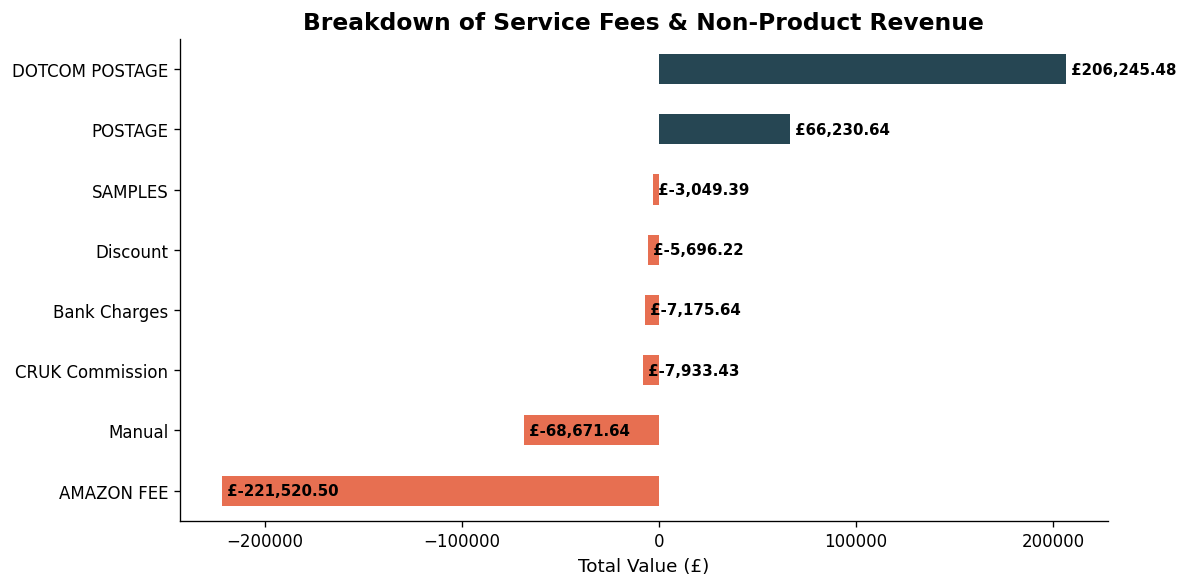

✅ Service fee chart saved to service_fee_distribution.png


In [42]:
# Visualize total value of service fees (Filtering only zero-value Samples)
plt.figure(figsize=(10, 5))

# Filter logic: Keep everything EXCEPT rows where Description is 'SAMPLES' AND Sales is 0
is_sample = df_fees['Description'].str.upper().str.strip().isin(['SAMPLES', 'SAMPLE'])
is_zero = df_fees['Sales'] == 0

fee_summary = df_fees[~(is_sample & is_zero)].groupby('Description')['Sales'].sum().sort_values()

# Use different colors for costs (red/orange) vs revenue (teal/dark blue)
colors = ['#264653' if x > 0 else '#E76F51' for x in fee_summary.values]
ax = fee_summary.plot(kind='barh', color=colors)

plt.title("Breakdown of Service Fees & Non-Product Revenue", fontweight='bold')
plt.xlabel("Total Value (£)")
plt.ylabel("")

# Add value labels
for i, v in enumerate(fee_summary.values):
    plt.text(v, i, f' £{v:,.2f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig("service_fee_distribution.png", bbox_inches="tight", dpi=150)
plt.show()
print("✅ Service fee chart saved to service_fee_distribution.png")

### Top Products by Net Revenue (Including Returns)
Visualisasi penjualan produk termasuk barang return.

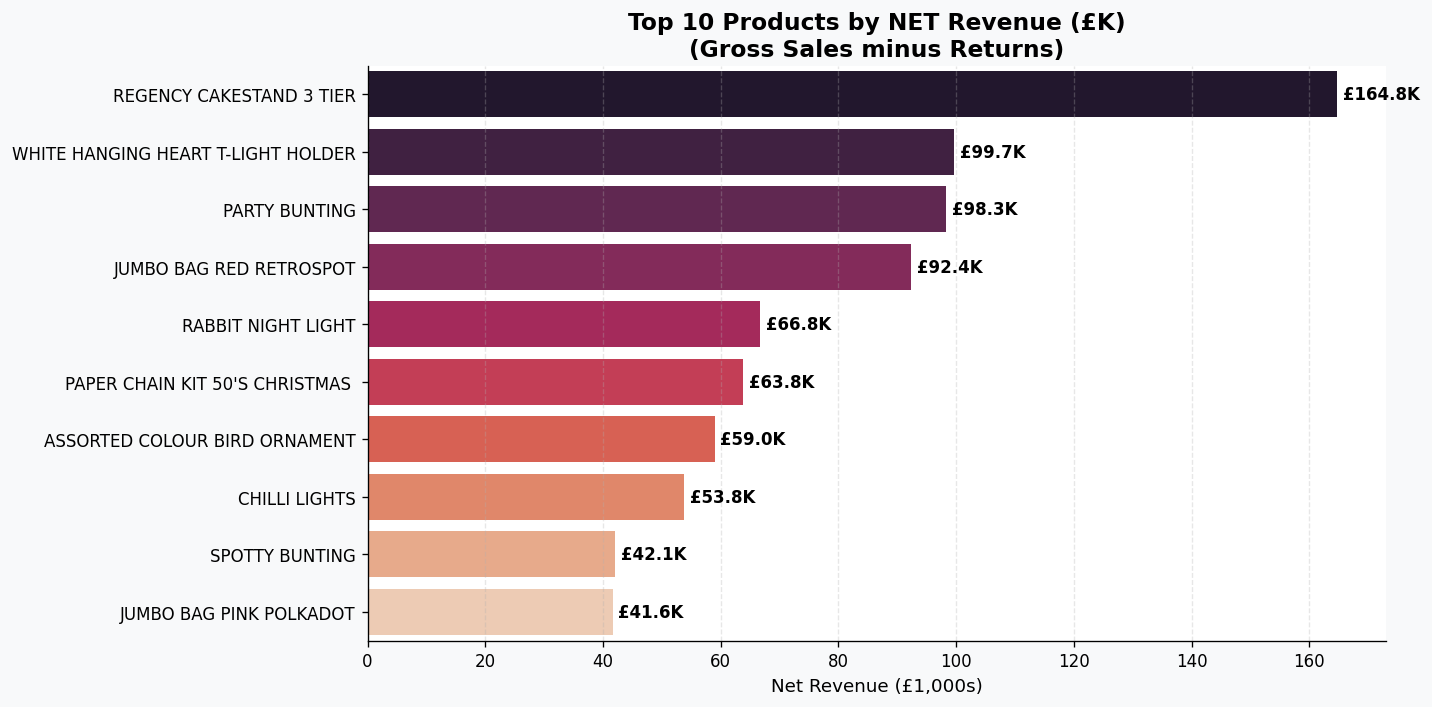

✅ Net Revenue chart saved to top_products_net.png


In [74]:
# 1. Calculate Net Revenue per Product
# We filter out service fees and use 'df' which contains all transactions
net_performance = df[~df['Description'].str.upper().str.strip().isin(service_codes)].groupby('Description').agg(
    Net_Revenue=('Net_Sales', 'sum')
).sort_values('Net_Revenue', ascending=False).head(10)

# 2. Visualize
plt.figure(figsize=(12, 6))
# FIX: Use plt.gcf() to get the figure object before accessing .patch
plt.gcf().patch.set_facecolor('#F8F9FA')

ax = sns.barplot(
    x=net_performance['Net_Revenue'] / 1000,
    y=net_performance.index,
    palette='rocket'
)

plt.title("Top 10 Products by NET Revenue (£K)\n(Gross Sales minus Returns)", fontsize=14, fontweight='bold')
plt.xlabel("Net Revenue (£1,000s)")
plt.ylabel("")

# Add value labels
for i, v in enumerate(net_performance['Net_Revenue'] / 1000):
    ax.text(v + 1, i, f'£{v:,.1f}K', va='center', fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig("top_products_net.png", bbox_inches="tight", dpi=150)
plt.show()
print("✅ Net Revenue chart saved to top_products_net.png")

## Cell 7 — Step 5: Business Insights
> ✏️ **Isi insight-mu di sini!** Ubah teks placeholder dengan temuan dari analisismu.

In [71]:
# Calculate support figures for insights
uk_sales_share = (df_sales[df_sales['Country'] == 'United Kingdom']['Sales'].sum() / total_revenue) * 100
peak_hour = hourly_sales['Sales'].idxmax()
top_product_name = top_products.index[0]

# Guest vs Registered Analysis
guest_revenue = df_sales[df_sales['CustomerID'] == 'Guest Checkout']['Sales'].sum()
guest_pct = (guest_revenue / total_revenue) * 100

# Paper Craft check
paper_craft_net = net_performance.loc['PAPER CRAFT , LITTLE BIRDIE', 'Net_Revenue'] if 'PAPER CRAFT , LITTLE BIRDIE' in net_performance.index else 0

print("=" * 55)
print("📊 BUSINESS INSIGHTS & RECOMMENDATIONS")
print("=" * 55)
print(f"""
💡 INSIGHT 1 — MARKET CONCENTRATION
   Pasar United Kingdom mendominasi {uk_sales_share:.1f}% dari total revenue.
   → Lakukan diversifikasi kampanye marketing ke negara yang memberi revenue
     tinggi seperti Netherlands dan EIRE untuk mengurangi ketergantungan.

💡 INSIGHT 2 — PEAK OPERATIONAL HOURS
   Transaksi banyak dilakukan pada jam 10:00 - 15:00,
   dengan puncak transaksi terjadi pada pukul {peak_hour}:00.
   → Optimalkan jumlah staff CS dan server pada jam 10:00 - 15:00.

💡 INSIGHT 3 — GUEST CHECKOUTS (RETENTION RISK)
   Sebanyak {guest_pct:.1f}% revenue (£{guest_revenue/1000:,.1f}K)
   berasal dari Customer ID kosong (asumsi dari Guest Checkout).
   → Tawarkan insentif (misal diskon) agar guest membuat akun.

💡 INSIGHT 4 — DATA ANOMALY (PAPER CRAFT)
   Produk 'PAPER CRAFT, LITTLE BIRDIE' memiliki pendapatan kotor terbesar,
   namun ternyata pendapatan bersihnya £{paper_craft_net:,.2f} karena pengembalian.
   → Gunakan Net Revenue sebagai acuan performa produk yang sebenarnya.

💡 INSIGHT 5 — PRODUCT FOCUS
   Produk '{top_product_name}' adalah kontributor revenue terbesar.
   → Pastikan safety stock terjaga untuk Top 10 best-seller.

💡 INSIGHT 6 — REVENUE AND EXPENSES CONTRIBUTOR
   Kontributor revenue terbesar justru bukan dari penjualan produk,
   melainkan dari layanan 'DOTCOM POSTAGE'.
   Begitu juga dengan pengeluaran terbesar disebabkan oleh biaya
   layanan 'AMAZON FEE'.

💡 REKOMENDASI:
   1.
   2.
   3.
""")

📊 BUSINESS INSIGHTS & RECOMMENDATIONS

💡 INSIGHT 1 — MARKET CONCENTRATION
   Pasar United Kingdom mendominasi 85.1% dari total revenue.
   → Lakukan diversifikasi kampanye marketing ke negara yang memberi revenue
     tinggi seperti Netherlands dan EIRE untuk mengurangi ketergantungan.

💡 INSIGHT 2 — PEAK OPERATIONAL HOURS
   Transaksi banyak dilakukan pada jam 10:00 - 15:00,
   dengan puncak transaksi terjadi pada pukul 12:00.
   → Optimalkan jumlah staff CS dan server pada jam 10:00 - 15:00.

💡 INSIGHT 3 — GUEST CHECKOUTS (RETENTION RISK)
   Sebanyak 14.8% revenue (£1,522.5K) 
   berasal dari Customer ID kosong (asumsi dari Guest Checkout).
   → Tawarkan insentif (misal diskon) agar guest membuat akun.

💡 INSIGHT 4 — DATA ANOMALY (PAPER CRAFT) 
   Produk 'PAPER CRAFT, LITTLE BIRDIE' memiliki pendapatan kotor terbesar, 
   namun ternyata pendapatan bersihnya £0.00 karena pengembalian.
   → Gunakan Net Revenue sebagai acuan performa produk yang sebenarnya.

💡 INSIGHT 5 — PRODUCT FOCUS


## Cell 8 — ✏️ YOUR TURN — Challenge Tasks

Selesaikan tasks berikut untuk memperkuat portfolio kamu:

In [63]:
# LEVEL 1: Wajib diselesaikan

# Task 1: Hitung CLV sederhana
# clv = df.groupby("Customer Name")["Sales"].agg(["sum","count"])
# clv.columns = ["Total_Spend", "Num_Orders"]
# clv["Avg_Order"] = clv["Total_Spend"] / clv["Num_Orders"]
# print(clv.sort_values("Total_Spend", ascending=False).head(10))

# Task 2: Top 5 Sub-Category paling rugi
# print(df.groupby("Sub-Category")["Profit"].sum().sort_values().head(5))

# Task 3: Profitabilitas per Segment
# print(df.groupby("Segment").agg(Sales=("Sales","sum"), Profit=("Profit","sum")))

# ── Hapus komentar (#) di atas untuk menjalankan ──────────────────────────
print("💡 Hapus komentar di cell ini satu per satu dan jalankan!")


💡 Hapus komentar di cell ini satu per satu dan jalankan!


---
## 🏁 Next Steps
1. Selesaikan **Challenge Tasks** di Cell 8
2. Simpan sebagai `ecommerce_analysis.ipynb`
3. Upload ke **GitHub** (buat repo: `ecommerce-sales-analysis`)
4. Screenshot **2–3 chart terbaik**
5. Buat **LinkedIn Post** dalam 7 hari!

```
Template Caption LinkedIn:
"[Hook sentence] 💡
📊 Analisis: Superstore Sales Dataset
🛠️ Tools: Python | Pandas | Seaborn
🔍 Key Findings:
• [Insight 1]
• [Insight 2]
• [Insight 3]
👉 Full notebook: [GitHub link]
#DataAnalytics #Python #Portfolio"
```

**Good luck! Kamu pasti bisa 🚀**